In [1]:
# python
import sys
import importlib
# columnar analysis
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from coffea import processor
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import sidm_processor, utilities, scaleout, selection, llpnanoaodschema
#from sidm.tools import llpnanoaodschema_0726 as llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(sidm_processor)
importlib.reload(utilities)
importlib.reload(scaleout)
importlib.reload(selection)
importlib.reload(llpnanoaodschema)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
from hist import Hist

In [10]:
client = scaleout.make_dask_client("tls://localhost:8786")
client

<Client: 'tls://192.168.121.140:8786' processes=1 threads=1, memory=3.82 GiB>

In [8]:
 samples = [
   "TTJets", 

]
fileset = utilities.make_fileset(samples, 
                                 "llpNanoAOD_v2", 
                                 location_cfg="backgrounds.yaml",
                                 # max_files =100
                                  max_files = 1
                                )


runner = processor.Runner(
    #executor=processor.IterativeExecutor(),
    executor=processor.DaskExecutor(client=client),
    #schema=NanoAODSchema,
    #schema=llpnanoaodschema.NanoAODSchema,
    schema=llpnanoaodschema.LLPNanoAODSchema,
    #maxchunks=1,
    skipbadfiles=True,
)

channels = [
    '2mu_2LJ_CCnocharge',
    '2mu_2LJ_CC',
    '2LJ_CCnocharge',
    '2LJ_CC',
    'only2mu_2LJ_CCnocharge',
    'only2mu_2LJ_CC',
]

p = sidm_processor.SidmProcessor(
    channels,
    ["base"],
    verbose=True,
)


out = {}
for i, sample in enumerate(samples):
    print(f"Processing {sample}")
    fileset_one_sample = {samples[i]:fileset.get(samples[i])}
    output = runner.run(fileset_one_sample, treename='Events', processor_instance=p)
    #Add this sample's output to the out variable
    out[sample] = output["out"][sample]



Output()

Processing TTJets


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value 
encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))

...

Applying photons Custom Cutbased

Applying photons pixelSeed

Applying photons Photon DR Veto 0p025

Applying dsaMuons segmatch veto + dR outer + num seg

KeyboardInterrupt: 

Text(0.5, 1.07, 'TTJets')

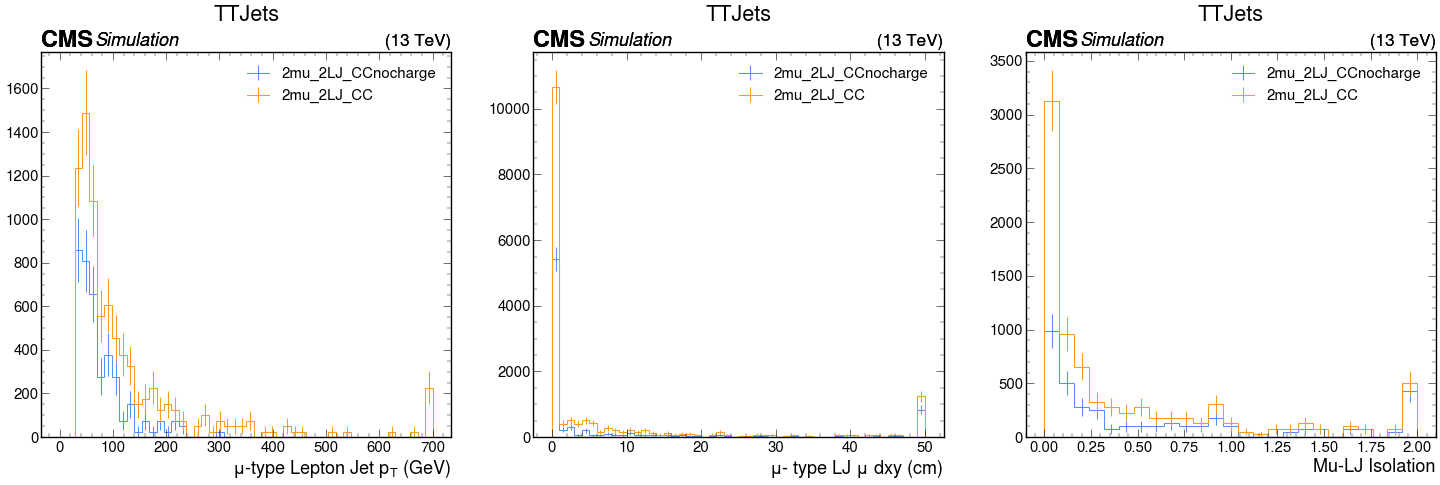

In [19]:
plt.subplots(1, 3, figsize=(36,10))
plt.subplot(1, 3, 1)
channel1 = 0
channel2 = 1
utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channels[channel2], ::2j],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

plt.subplot(1, 3, 2)
utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channels[channel2], ::2j],label=channels[channel2])
plt.legend()
plt.title(samples[0],y=1.07)

plt.subplot(1, 3, 3)
utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channels[channel2], ::2j],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)


In [17]:
print(channels[0])
out[samples[0]]["cutflow"][channels[0]].print_table()
print()

print(channels[1])
out[samples[0]]["cutflow"][channels[1]].print_table()
print()

2mu_2LJ_CCnocharge
cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection           28221812.0   28221812.0
PV filter              28221812.0   28221812.0
pass triggers            483856.9     483856.9
>=2 LJs                    3782.9       1751.3

2mu_2LJ_CC
cut name         individual cut N    all cut N
-------------  ------------------  -----------
No selection           28221812.0   28221812.0
PV filter              28221812.0   28221812.0
pass triggers            483856.9     483856.9
>=2 LJs                    7425.6       3993.0



Text(0.5, 1.07, 'TTJets')

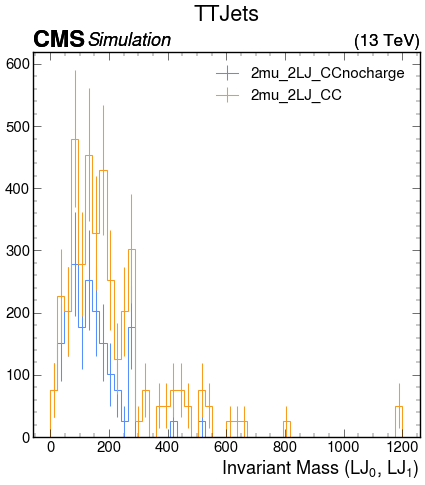

In [20]:
channel1 = 0
channel2 = 1
utilities.plot(out[samples[0]]["hists"]["lj_lj_invmass"][channels[channel1], ::2j],label=channels[channel1])
utilities.plot(out[samples[0]]["hists"]["lj_lj_invmass"][channels[channel2], ::2j],label=channels[channel2])
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

In [11]:
CC_ljs = 101378.9072265625
CC0charge_ljs = 78782.40380859375
print(f'{(CC_ljs / CC0charge_ljs)*100:.2f}%')

128.68%


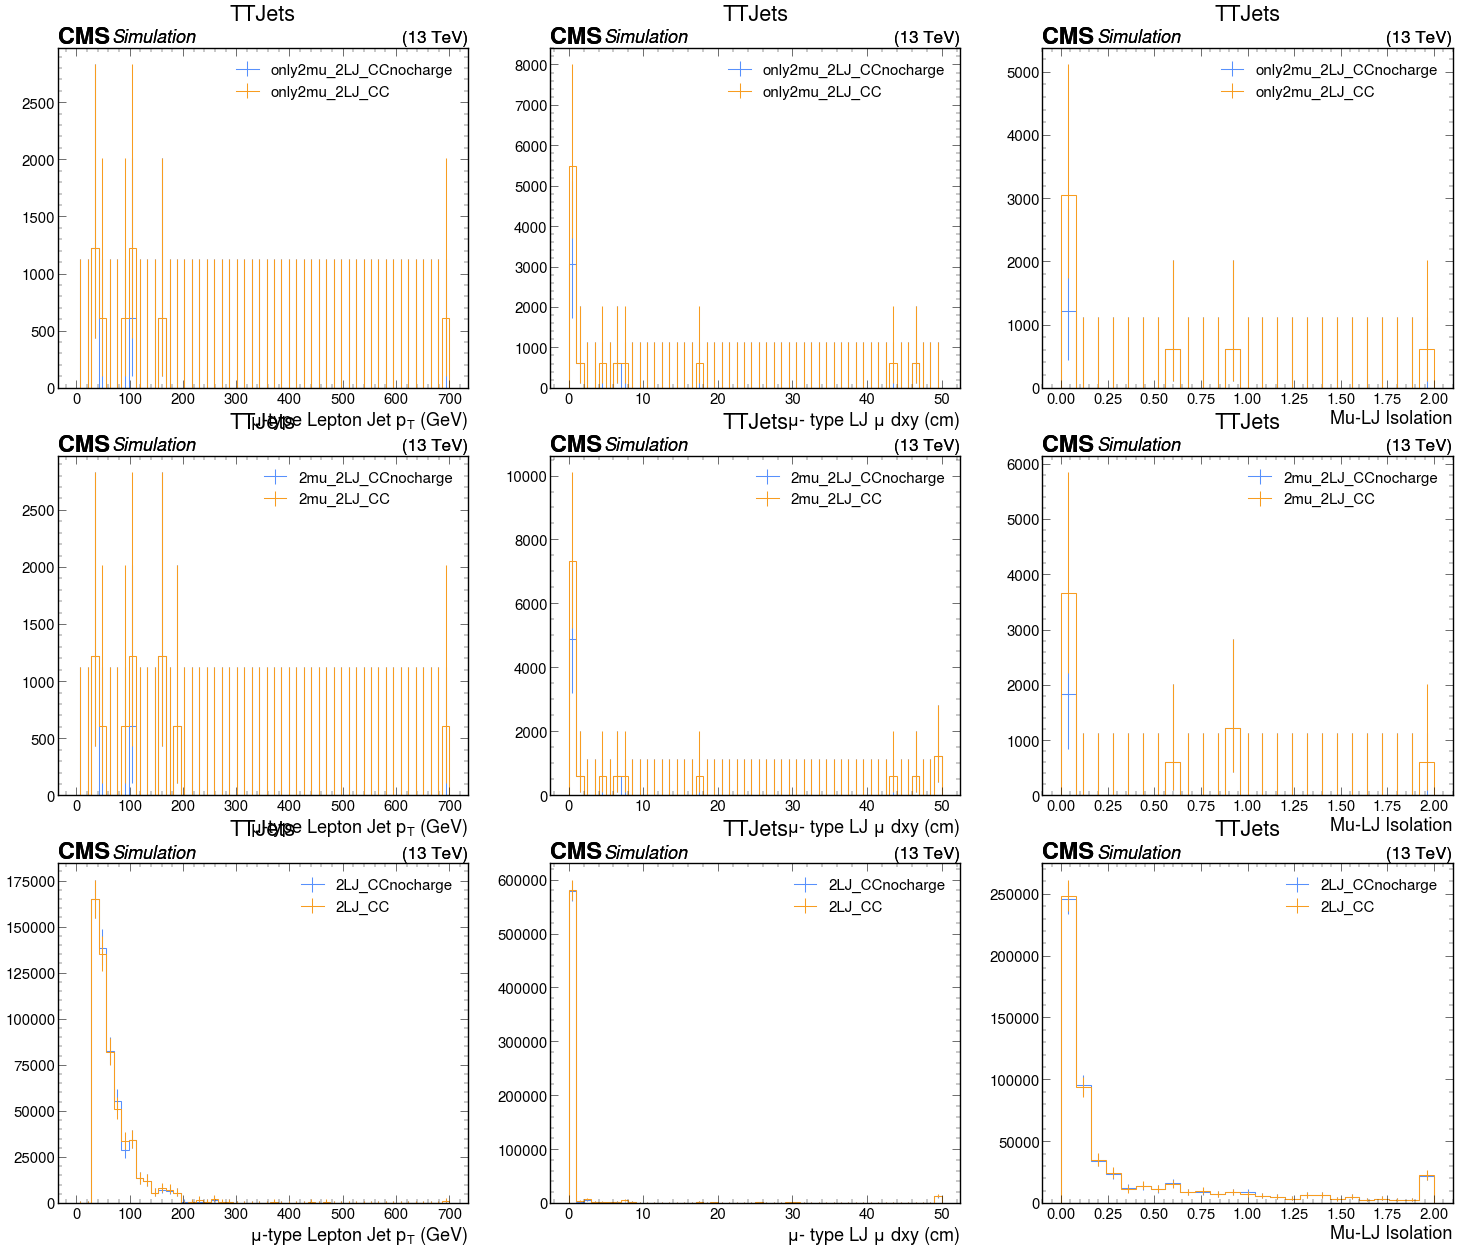

In [7]:
channel = [['only2mu_2LJ_CCnocharge','only2mu_2LJ_CC'],['2mu_2LJ_CCnocharge','2mu_2LJ_CC'],['2LJ_CCnocharge','2LJ_CC']]
plt.subplots(len(channel), 3, figsize=(36,30))
for i in range(len(channel)):
    plt.subplot(len(channel), 3, 1+i*3)
    channel1 = channel[i][0]
    channel2 = channel[i][1]
    utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channel1, ::2j],label=channel1)
    utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channel2, ::2j],label=channel2)
    #plt.yscale("log")
    plt.legend()
    plt.title(samples[0],y=1.07)

    plt.subplot(len(channel), 3, 2+i*3)
    utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channel1, ::2j],label=channel1)
    utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channel2, ::2j],label=channel2)
    plt.legend()
    plt.title(samples[0],y=1.07)

    plt.subplot(len(channel), 3, 3+i*3)
    utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channel1, ::2j],label=channel1)
    utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channel2, ::2j],label=channel2)
    #plt.yscale("log")
    plt.legend()
    plt.title(samples[0],y=1.07)
